# Progetto MLDA: Diabetes Health Indicators (BRFSS 2015) — Classificazione multiclasse dello stato di diabete

## Obiettivo
L’obiettivo del progetto è costruire e valutare modelli di *machine learning supervisionato* per predire lo stato di diabete di un individuo a partire da indicatori sanitari, abitudini di vita e caratteristiche demografiche, utilizzando il dataset **BRFSS 2015** (*Behavioral Risk Factor Surveillance System*).

## Target (Diabetes_012)
La variabile target è Diabetes_012, definita come segue:
- **0** → No diabetes  
- **1** → Prediabetes  
- **2** → Diabetes

## Descrizione delle feature
Il dataset contiene **21 feature**, che descrivono condizioni cliniche, abitudini di vita e caratteristiche socio-demografiche degli individui.

#### Indicatori clinici e di salute
- **HighBP**: presenza di pressione sanguigna alta  
  0 = no, 1 = sì

- **HighChol**: presenza di colesterolo alto  
  0 = no, 1 = sì

- **CholCheck**: controllo del colesterolo effettuato negli ultimi 5 anni  
  0 = no, 1 = sì

- **BMI**: Body Mass Index (indice di massa corporea)

- **Stroke**: diagnosi pregressa di ictus  
  0 = no, 1 = sì

- **HeartDiseaseorAttack**: presenza di malattia coronarica (CHD) o infarto miocardico (MI)  
  0 = no, 1 = sì

- **GenHlth**: stato di salute generale percepito  
  scala 1–5: 1 = eccellente, 2 = molto buono, 3 = buono, 4 = discreto, 5 = scarso

- **MentHlth**: numero di giorni (negli ultimi 30) in cui la salute mentale non è stata buona  
  scala 0–30 giorni

- **PhysHlth**: numero di giorni (negli ultimi 30) in cui la salute fisica non è stata buona  
  scala 0–30 giorni

- **DiffWalk**: difficoltà serie nel camminare o salire le scale  
  0 = no, 1 = sì

#### Abitudini e stile di vita
- **Smoker**: ha fumato almeno 100 sigarette nella vita (≈ 5 pacchetti)  
  0 = no, 1 = sì

- **PhysActivity**: attività fisica svolta negli ultimi 30 giorni (escluso lavoro)  
  0 = no, 1 = sì

- **Fruits**: consumo di frutta almeno una volta al giorno  
  0 = no, 1 = sì

- **Veggies**: consumo di verdura almeno una volta al giorno  
  0 = no, 1 = sì

- **HvyAlcoholConsump**: consumo elevato di alcol (uomini >14 drink/settimana, donne >7 drink/settimana)  
  0 = no, 1 = sì

#### Accesso alle cure sanitarie
- **AnyHealthcare**: possesso di una qualsiasi forma di copertura sanitaria  
  0 = no, 1 = sì

- **NoDocbcCost**: impossibilità di vedere un medico negli ultimi 12 mesi per motivi economici  
  0 = no, 1 = sì

#### Caratteristiche demografiche e socioeconomiche
- **Sex**: sesso biologico  
  0 = femmina, 1 = maschio

- **Age**: classe di età (13 livelli)  
  scala 1-13: 1 = 18–24, 2 = 25–29, 3 = 30–34, 4 = 35–39, 5 = 40–44, 6 = 45–49, 7 = 50–54, 8 = 55–59, 9 = 60–64, 10 = 65–69, 11 = 70–74, 12 = 75–79, 13 = 80 o più

- **Education**: livello di istruzione  
  scala 1–6: 1 = nessuna istruzione/scuola dell’infanzia, 2 = scuola primaria, 3 = scuola superiore (parziale), 4 = diploma/GED, 5 = college (1–3 anni), 6 = laurea o superiore

- **Income**: fascia di reddito
  scala 1–8: 1 = <＄10,000, 2 = ＄10,000 – ＄14,999, 3 = ＄15,000 – ＄19,999, 4 = ＄20,000 – ＄24,999, 5 = ＄25,000 – ＄34,999, 6 = ＄35,000 – ＄49,999, 7 = ＄50,000 – ＄74,999, 8 = ≥＄75,000



In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

TARGET_COL = "Diabetes_012"

df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))

print("\nInfo:")
df.info()

print("\nCount different values for each column:")
print(df.nunique())

print("\nFirst rows:")
display(df.head())


Shape: (253680, 22)

Columns: ['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9 

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [133]:
missing = df.isna().sum()
print("Missing values (total):", missing.sum())
if missing.sum() == 0:
    print("No missing values detected.")
else:
    display(missing[missing > 0])

n_dup = df.duplicated().sum()
print(f"\nDuplicated rows: {n_dup} ({n_dup / len(df) * 100:.2f}%)")

tol = 1e-9
non_integer_cols = [c for c in df.columns if (np.abs(df[c] - np.round(df[c])) > tol).any()]
print("\nColumns with non-integer values:", non_integer_cols)

if len(non_integer_cols) == 0:
    df = df.astype(int)

binary_cols = [
    "HighBP","HighChol","CholCheck","Smoker","Stroke","HeartDiseaseorAttack",
    "PhysActivity","Fruits","Veggies","HvyAlcoholConsump","AnyHealthcare",
    "NoDocbcCost","DiffWalk","Sex"
]
ordinal_cols = ["GenHlth","Age","Education","Income"]
numeric_cols = ["BMI","MentHlth","PhysHlth"]
    
print("\nBinary features: unique values check")
for c in binary_cols:
    vals = sorted(df[c].unique().tolist())
    print(f"- {c}: {vals}")    

print("\nMin/max check (ordinal + numeric + target)")
for c in ordinal_cols + numeric_cols + [TARGET_COL]:
    print(f"- {c}: min={df[c].min()}, max={df[c].max()}")


Missing values (total): 0
No missing values detected.

Duplicated rows: 23899 (9.42%)

Columns with non-integer values: []

Binary features: unique values check
- HighBP: [0, 1]
- HighChol: [0, 1]
- CholCheck: [0, 1]
- Smoker: [0, 1]
- Stroke: [0, 1]
- HeartDiseaseorAttack: [0, 1]
- PhysActivity: [0, 1]
- Fruits: [0, 1]
- Veggies: [0, 1]
- HvyAlcoholConsump: [0, 1]
- AnyHealthcare: [0, 1]
- NoDocbcCost: [0, 1]
- DiffWalk: [0, 1]
- Sex: [0, 1]

Min/max check (ordinal + numeric + target)
- GenHlth: min=1, max=5
- Age: min=1, max=13
- Education: min=1, max=6
- Income: min=1, max=8
- BMI: min=12, max=98
- MentHlth: min=0, max=30
- PhysHlth: min=0, max=30
- Diabetes_012: min=0, max=2


,count,percent (%)
Diabetes_012,,
0,213703,84.24
1,4631,1.83
2,35346,13.93


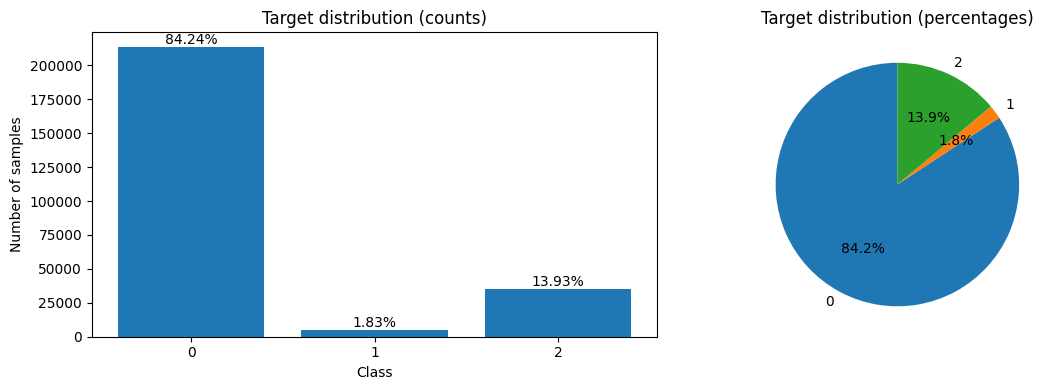

In [135]:
counts = df[TARGET_COL].value_counts().sort_index()
perc = (counts / counts.sum() * 100).round(2)

display(pd.DataFrame({"count": counts, "percent (%)": perc}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(counts.index.astype(str), counts.values)
axes[0].set_title("Target distribution (counts)")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of samples")

for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{perc.iloc[i]}%", ha="center", va="bottom")

axes[1].pie(
    counts.values,
    labels=counts.index.astype(str),
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Target distribution (percentages)")

plt.tight_layout()
plt.show()


## Distribuzione del target

La distribuzione del target evidenzia un forte sbilanciamento tra le classi:
- la classe **0 (no diabetes)** è largamente maggioritaria
- la classe **1 (prediabetes)** è estremamente rara (~2%)
- la classe **2 (diabetes)** rappresenta una minoranza significativa (~14%)

In [136]:
dup_mask = df.duplicated()
print(f"Duplicate rows: {dup_mask.sum()} ({dup_mask.mean()*100:.2f}%)")

counts_all = df[TARGET_COL].value_counts().sort_index()
counts_nodup = df.loc[~dup_mask, TARGET_COL].value_counts().sort_index()

dist = (
    pd.DataFrame({
        "count_all": counts_all,
        "pct_all": (counts_all / counts_all.sum() * 100),
        "count_no_duplicates": counts_nodup,
        "pct_no_duplicates": (counts_nodup / counts_nodup.sum() * 100),
    })
)

dist["delta_pct"] = dist["pct_no_duplicates"] - dist["pct_all"]
display(dist.round(4))

df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after duplicate removal: {df.shape}")


Duplicate rows: 23899 (9.42%)


,count_all,pct_all,count_no_duplicates,pct_no_duplicates,delta_pct
Diabetes_012,,,,,
0,213703,84.2412,190055,82.7114,-1.5298
1,4631,1.8255,4629,2.0145,0.1890
2,35346,13.9333,35097,15.2741,1.3408


Shape after duplicate removal: (229781, 22)


,count,percent (%)
Diabetes_012,,
0,190055,82.71
1,4629,2.01
2,35097,15.27


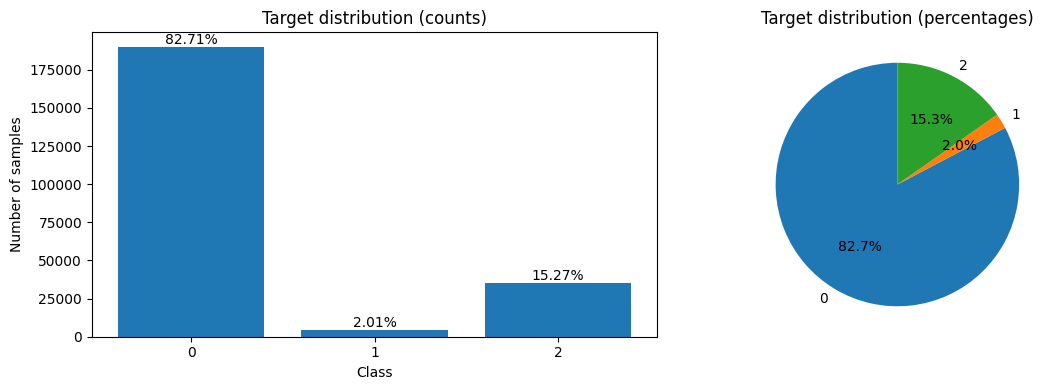

In [137]:
counts = df[TARGET_COL].value_counts().sort_index()
perc = (counts / counts.sum() * 100).round(2)

display(pd.DataFrame({"count": counts, "percent (%)": perc}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(counts.index.astype(str), counts.values)
axes[0].set_title("Target distribution (counts)")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of samples")

for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{perc.iloc[i]}%", ha="center", va="bottom")

axes[1].pie(
    counts.values,
    labels=counts.index.astype(str),
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Target distribution (percentages)")

plt.tight_layout()
plt.show()

### Sbilanciamento delle classi e scelta delle metriche

A causa del forte sbilanciamento, la **accuracy** non è una metrica informativa,
poiché valori elevati possono essere ottenuti semplicemente favorendo la classe
maggioritaria. Per questo motivo, viene utilizzata come metrica principale la
**F1-macro**, che assegna lo stesso peso a ciascuna classe e penalizza i modelli che
ottengono prestazioni scarse sulle classi minoritarie.

Come metrica di supporto viene inoltre utilizzata la **balanced accuracy**, utile per
valutare quanto i recall delle diverse classi siano equilibrati.

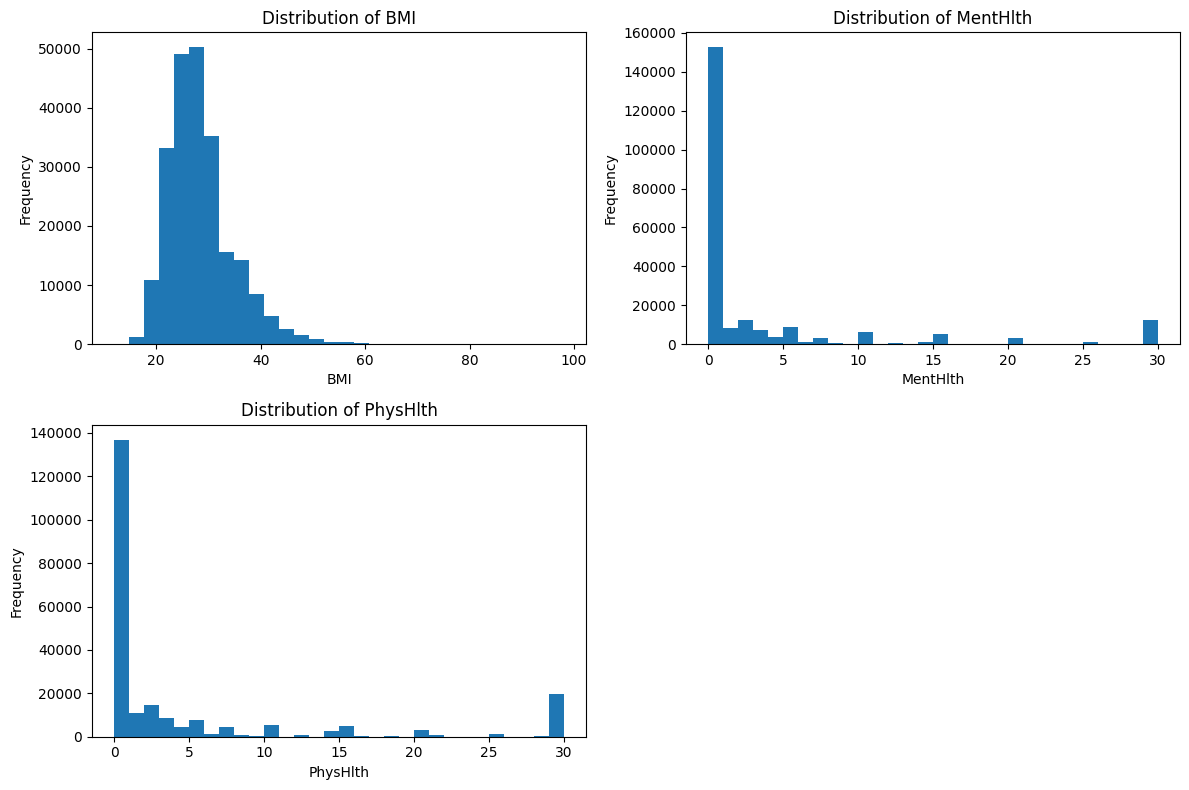

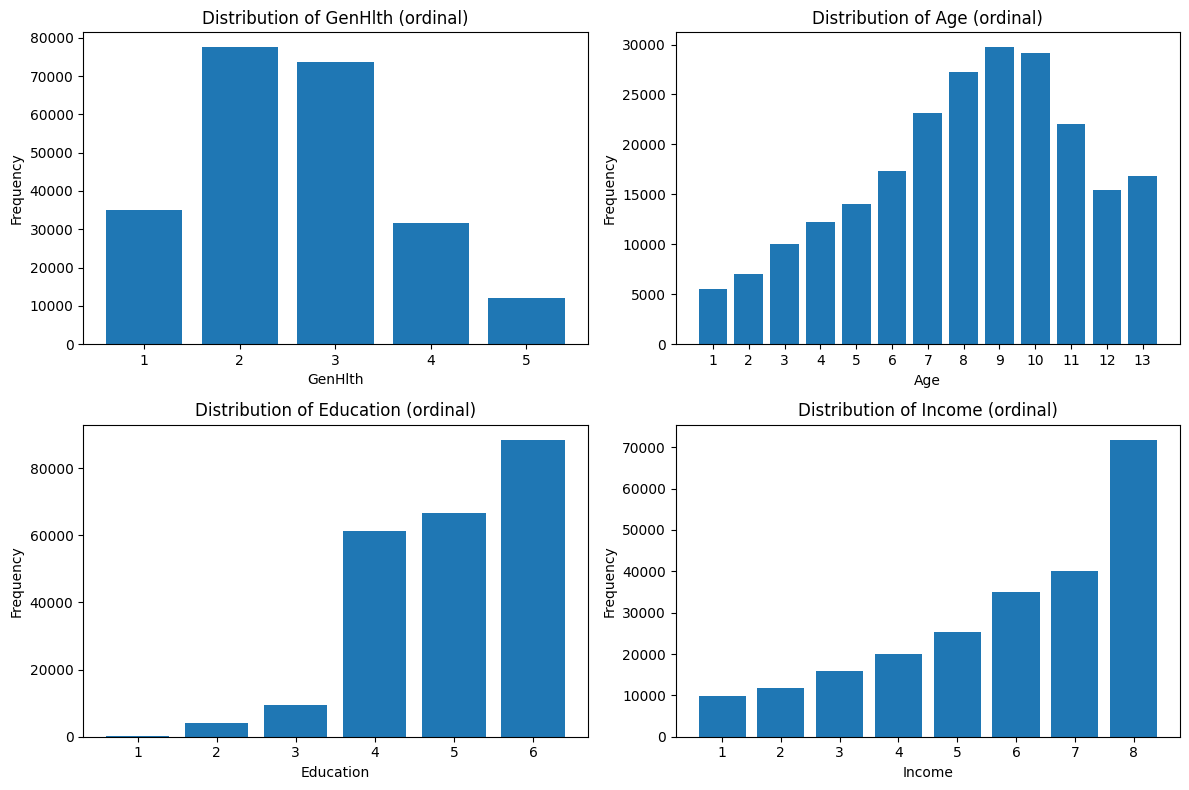

In [144]:
n_cols = 2
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

plt.figure(figsize=(6 * n_cols, 4 * n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

n_rows = int(np.ceil(len(ordinal_cols) / n_cols))

plt.figure(figsize=(6 * n_cols, 4 * n_rows))

for i, col in enumerate(ordinal_cols, 1):
    counts = df[col].value_counts().sort_index()
    plt.subplot(n_rows, n_cols, i)
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"Distribution of {col} (ordinal)")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


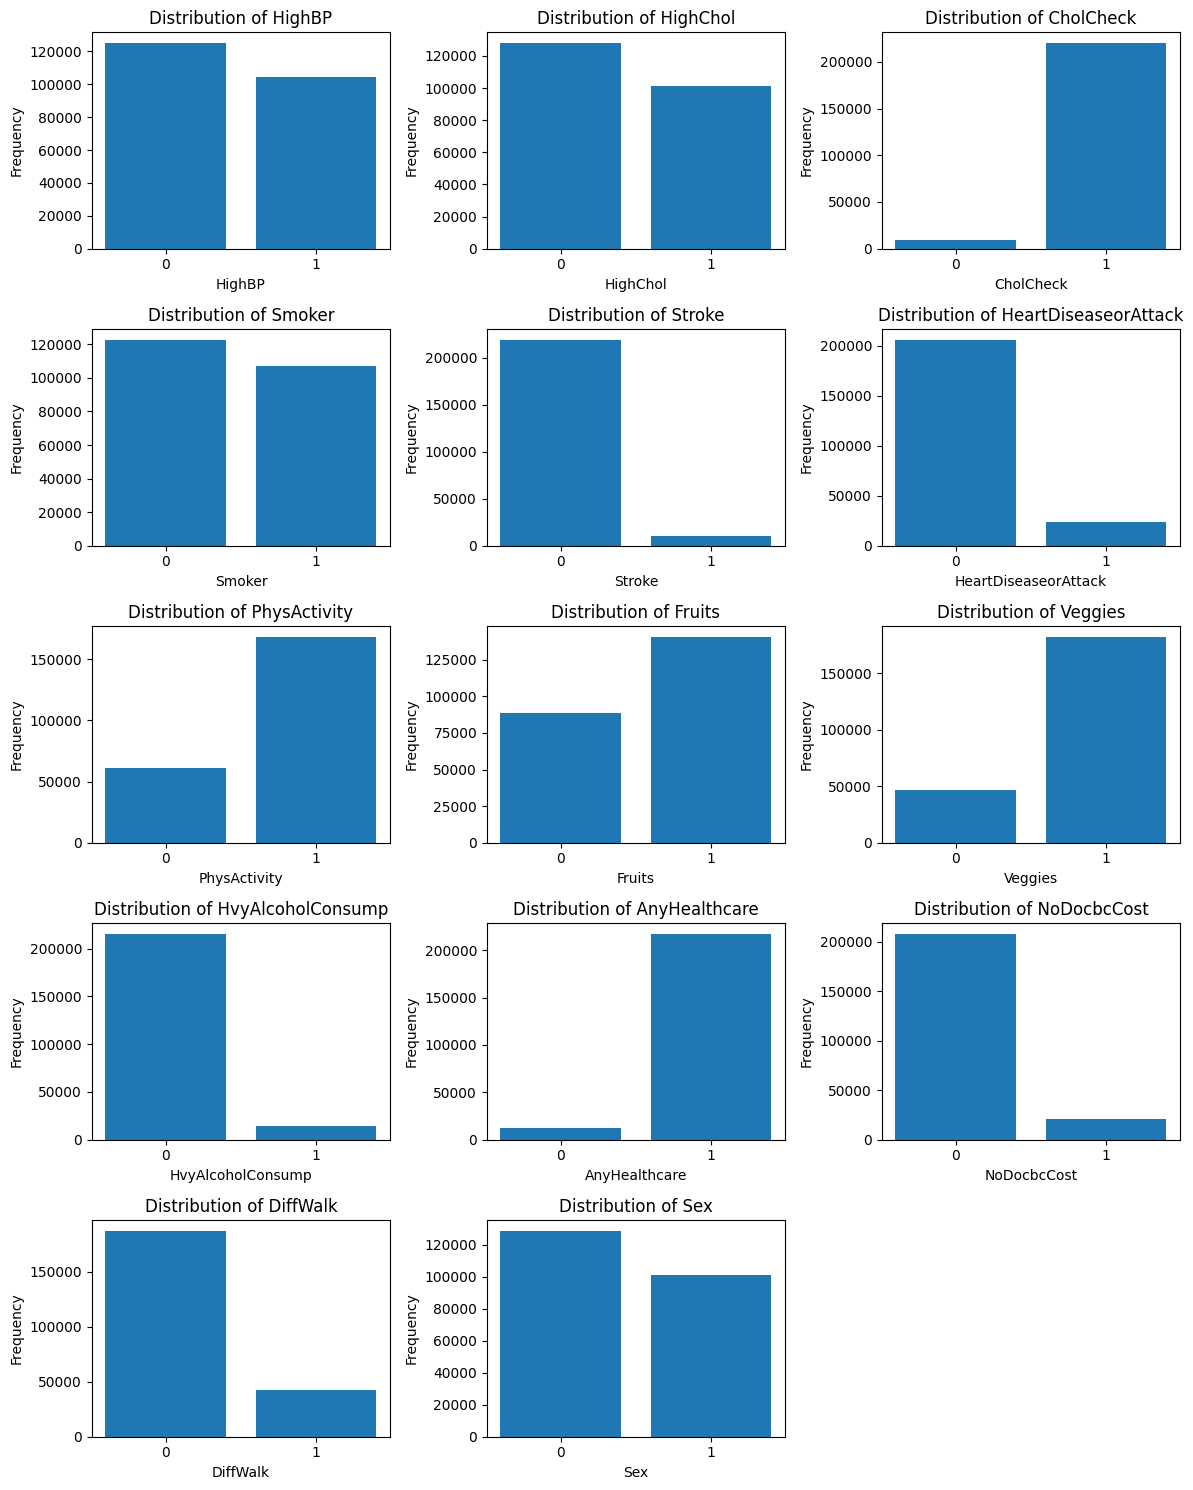

In [142]:
n_cols = 3 
n_rows = int(np.ceil(len(binary_cols) / n_cols))

plt.figure(figsize=(4 * n_cols, 3 * n_rows))

for i, col in enumerate(binary_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    counts = df[col].value_counts().sort_index()
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


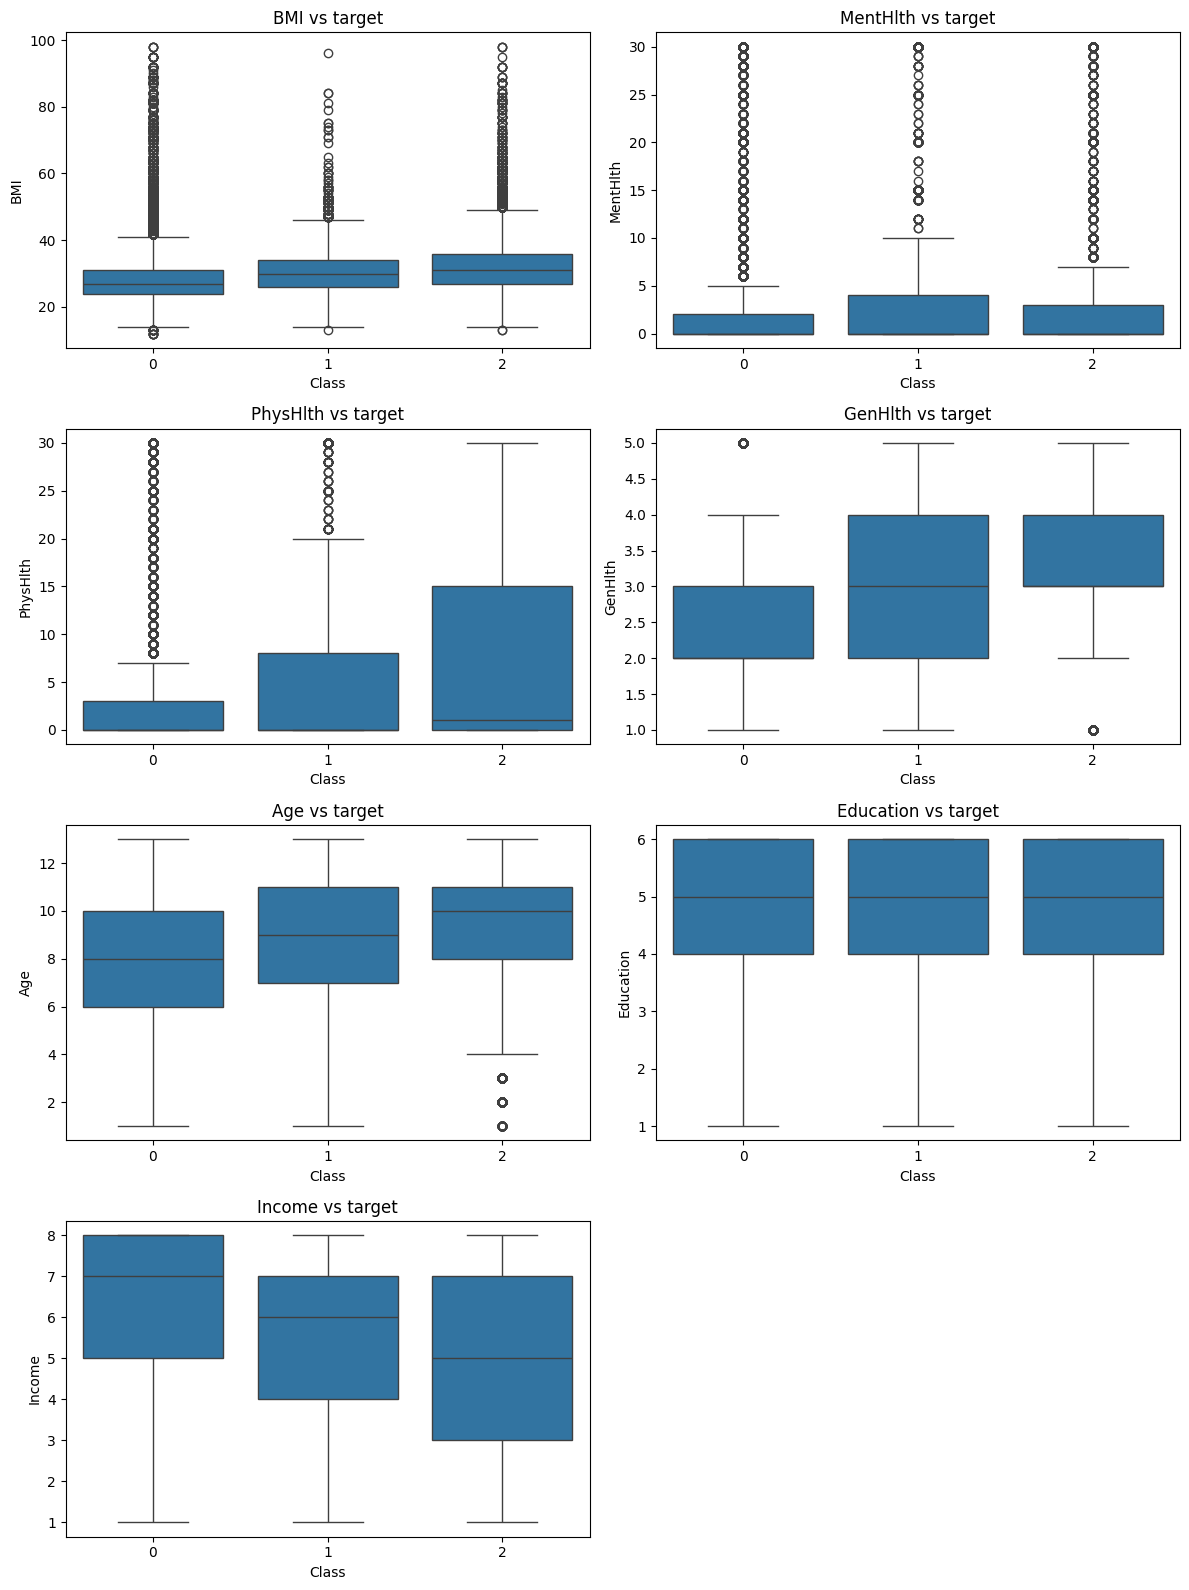

In [146]:
features_num_ord = numeric_cols + ordinal_cols

n_cols = 2
n_rows = int(np.ceil(len(features_num_ord) / n_cols))

plt.figure(figsize=(6 * n_cols, 4 * n_rows))

for i, col in enumerate(features_num_ord, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(
        x=TARGET_COL,
        y=col,
        data=df,
    )
    plt.title(f"{col} vs target")
    plt.xlabel("Class")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,DiffWalk,Sex
Diabetes_012,,,,,,,,,,,,,,
0,0.395175,0.395349,0.952672,0.455110,0.035521,0.079961,0.754055,0.618526,0.802815,0.067928,0.943622,0.089369,0.148520,0.432243
1,0.629078,0.620868,0.986606,0.492763,0.057248,0.143444,0.678332,0.602506,0.768849,0.044934,0.945129,0.129402,0.277598,0.437459
2,0.752344,0.669459,0.993133,0.519218,0.093113,0.223837,0.628515,0.584238,0.754908,0.023706,0.959484,0.106619,0.373650,0.477306



Top 10 binary features with the largest increase (class 2 vs class 0):


,delta(2-0)
HighBP,0.357168
HighChol,0.274110
DiffWalk,0.225130
HeartDiseaseorAttack,0.143876
Smoker,0.064108
Stroke,0.057592
Sex,0.045062
CholCheck,0.040462
NoDocbcCost,0.017250
AnyHealthcare,0.015862



Binary features with a decrease (negative delta, class 2 vs class 0):


,delta(2-0)
PhysActivity,-0.125540
Veggies,-0.047907
HvyAlcoholConsump,-0.044222
Fruits,-0.034288


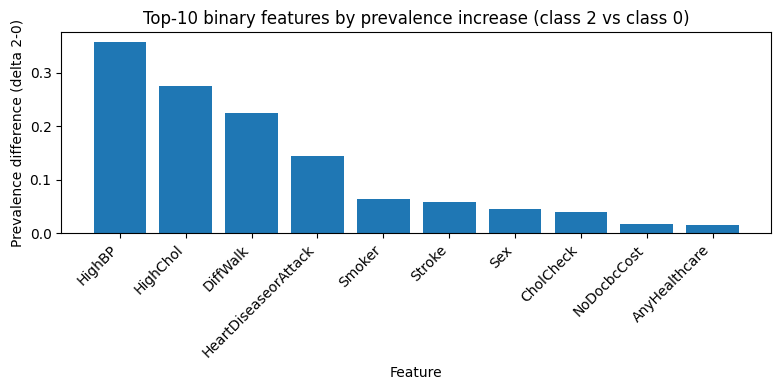

In [148]:
# For binary features, the mean corresponds to the prevalence (proportion of 1s) within each target class
bin_prev = df.groupby(TARGET_COL)[binary_cols].mean()
display(bin_prev)

bin_rank = (bin_prev.loc[2] - bin_prev.loc[0]).sort_values(ascending=False)
print("\nTop 10 binary features with the largest increase (class 2 vs class 0):")
display(bin_rank.head(10).to_frame("delta(2-0)"))

bin_rank_neg = bin_rank[bin_rank < 0].sort_values()  
print("\nBinary features with a decrease (negative delta, class 2 vs class 0):")
display(bin_rank_neg.to_frame("delta(2-0)"))

top10_inc = bin_rank.head(10)

plt.figure(figsize=(8, 4))
plt.bar(top10_inc.index, top10_inc.values)
plt.title("Top-10 binary features by prevalence increase (class 2 vs class 0)")
plt.xlabel("Feature")
plt.ylabel("Prevalence difference (delta 2-0)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


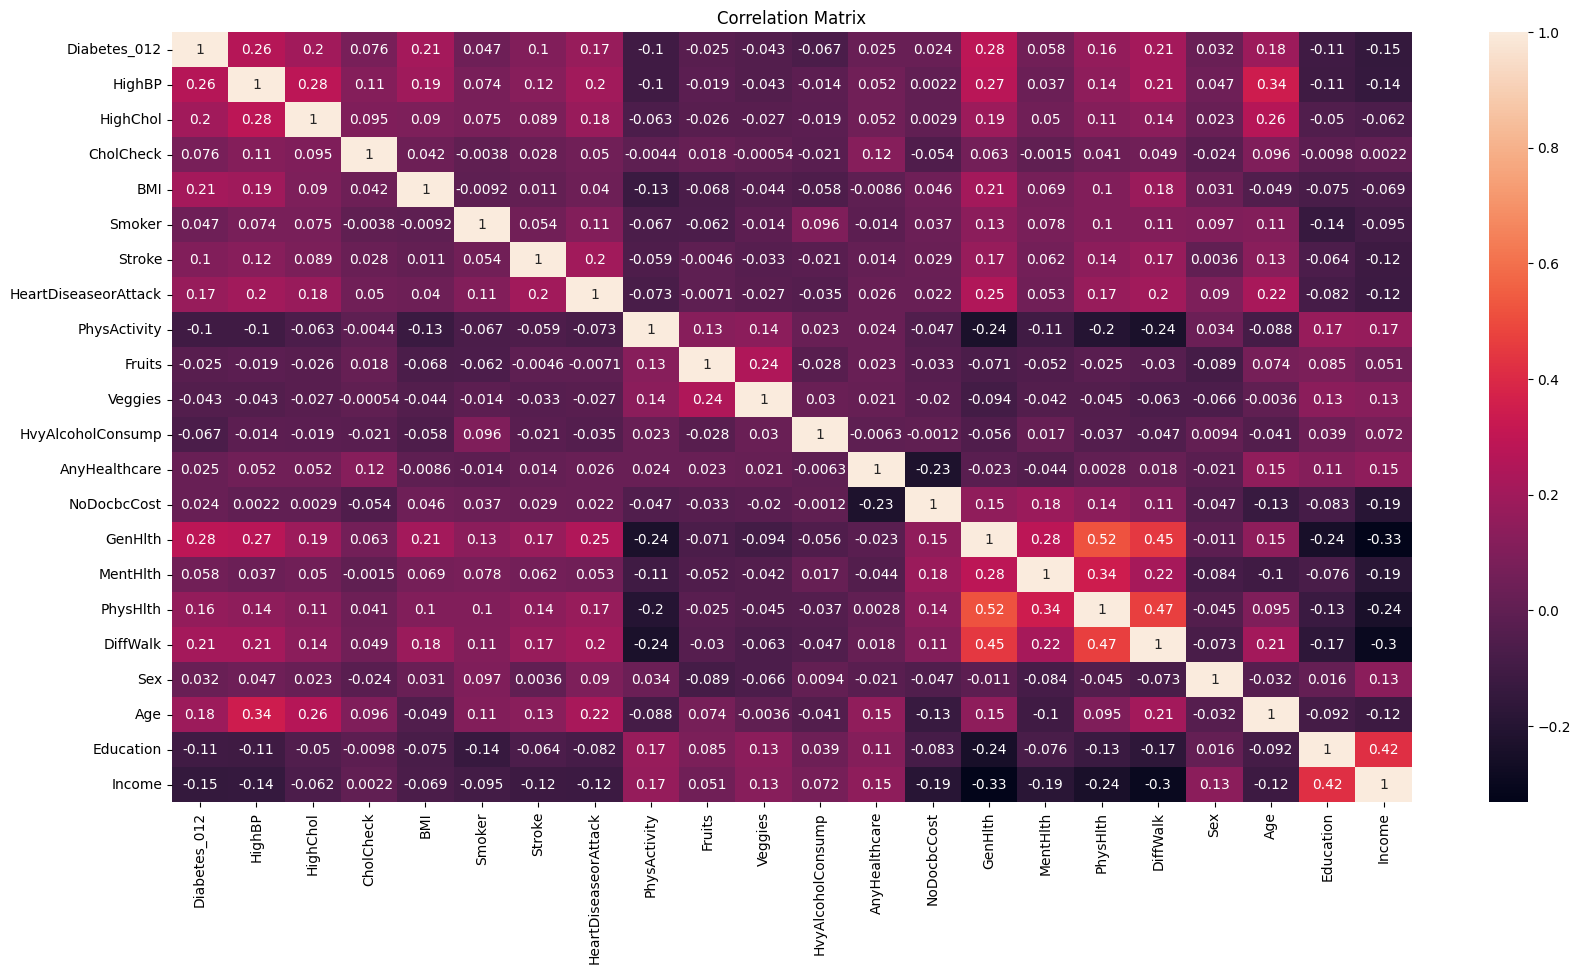

Top 10 most correlated feature pairs (|corr|):


,f1,f2,corr
309,GenHlth,PhysHlth,0.516508
352,PhysHlth,DiffWalk,0.466999
310,GenHlth,DiffWalk,0.446735
440,Education,Income,0.419354
330,MentHlth,PhysHlth,0.340362
39,HighBP,Age,0.339808
314,GenHlth,Income,-0.331935
377,DiffWalk,Income,-0.299267
13,Diabetes_012,GenHlth,0.284881
22,HighBP,HighChol,0.284186


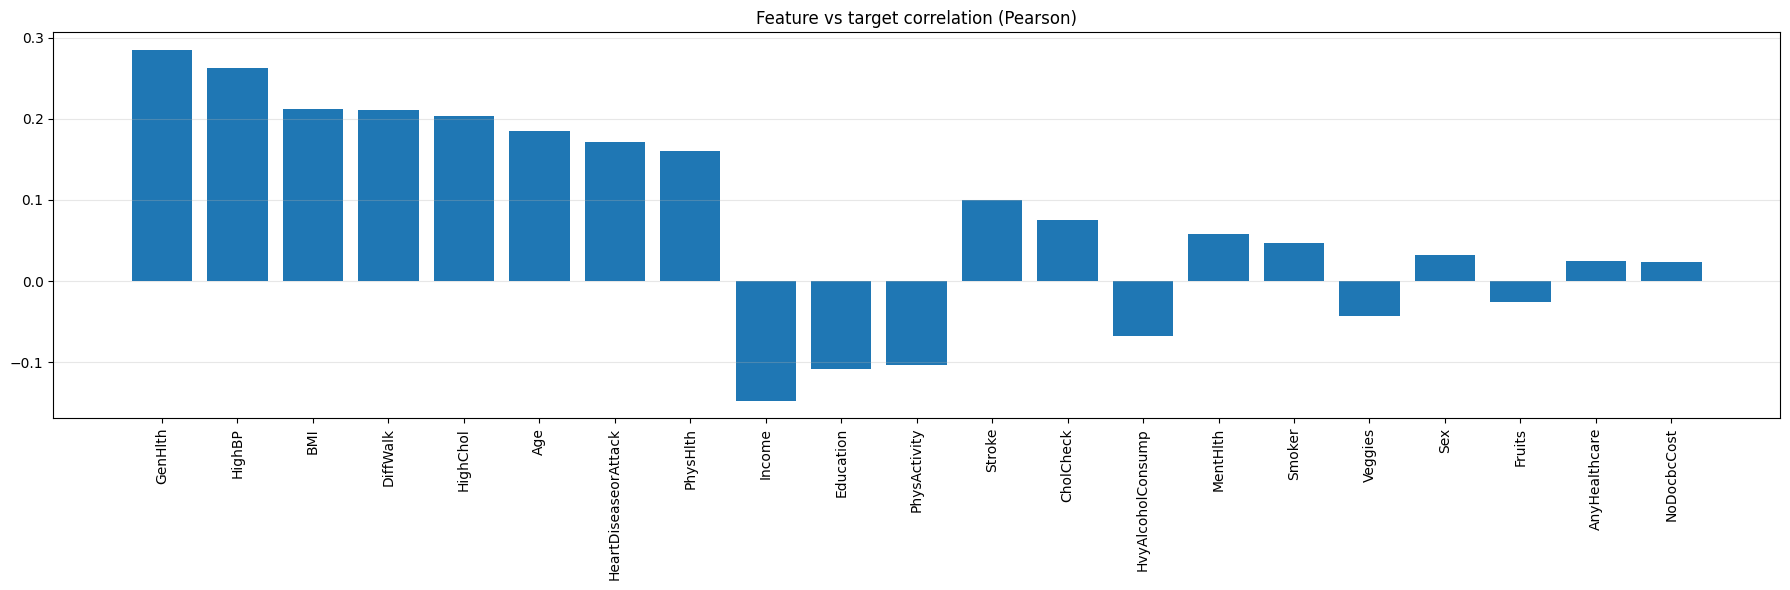

In [149]:
corr = df.corr()

plt.figure(figsize=(20, 10))
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

c = corr.copy()
np.fill_diagonal(c.values, np.nan)

pairs = (
    c.stack()
     .reset_index()
     .rename(columns={"level_0": "f1", "level_1": "f2", 0: "corr"})
)

pairs["abs_corr"] = pairs["corr"].abs()
pairs["pair"] = pairs.apply(
    lambda r: tuple(sorted([r["f1"], r["f2"]])),
    axis=1
)

pairs = pairs.drop_duplicates("pair").sort_values("abs_corr", ascending=False)

print("Top 10 most correlated feature pairs (|corr|):")
display(pairs.head(10)[["f1", "f2", "corr"]])

corr_target = (
    corr[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

plt.figure(figsize=(18, 6))
plt.bar(corr_target.index, corr_target.values)
plt.xticks(rotation=90)
plt.title("Feature vs target correlation (Pearson)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [153]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X = df.drop(columns=[TARGET_COL])
t = df[TARGET_COL]

X_vif = sm.add_constant(X)

vif = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})


vif = vif[vif["feature"] != "const"].sort_values("VIF", ascending=False)

display(vif.head(15))

,feature,VIF
14,GenHlth,1.716118
16,PhysHlth,1.594615
17,DiffWalk,1.511882
21,Income,1.431009
19,Age,1.353197
1,HighBP,1.301172
20,Education,1.272535
15,MentHlth,1.221802
7,HeartDiseaseorAttack,1.166983
2,HighChol,1.158172


In [89]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, balanced_accuracy_score

X_train_dev, X_test, t_train_dev, t_test = train_test_split(
    X, t,
    test_size=0.2,
    random_state=100,
    stratify=t
)

X_train, X_dev, t_train, t_dev = train_test_split(
    X_train_dev, t_train_dev,
    test_size=0.125,
    random_state=100,
    stratify=t_train_dev
)

print("Shapes:")
print("Train:", X_train.shape, "Dev:", X_dev.shape, "Test:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_dev_scaled   = scaler.transform(X_dev)
X_test_scaled  = scaler.transform(X_test)


Shapes:
Train: (160846, 21) Dev: (22978, 21) Test: (45957, 21)


**Logistic Regression**

- **C**: parametro di regolarizzazione del modello.  
  Valori piccoli di C impongono una regolarizzazione più forte, producendo un modello
  più semplice che può andare in underfitting. Valori grandi di C riducono la
  regolarizzazione, consentendo al modello di adattarsi maggiormente ai dati di training,
  con un rischio maggiore di overfitting.

- **class_weight = "balanced"**: assegna automaticamente un peso alle classi inversamente
  proporzionale alla loro frequenza nel dataset. Questo permette di gestire lo
  sbilanciamento delle classi, penalizzando maggiormente gli errori sulle classi
  minoritarie.


In [ ]:
logreg = LogisticRegression(class_weight="balanced")

# param_grid_lr = {
#     "C": [0.001, 0.01, 0.1, 1, 10]
# }

#  Fine search around the best C=0.001
param_grid_lr = {
    "C": [1e-4, 3e-4, 1e-3, 3e-3]
}

clf_lr = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid_lr,
    scoring="f1_macro",
    n_jobs=-1,
    cv=5,
    verbose=10,
    refit=True
)

clf_lr.fit(X_train_scaled, t_train)

print("Best params:", clf_lr.best_params_)
print("Best CV f1_macro:", round(clf_lr.best_score_, 4))

t_dev_pred = clf_lr.predict(X_dev_scaled)

print("\nDEV f1_macro:", round(f1_score(t_dev, t_dev_pred, average="macro"), 4))
print("DEV balanced_accuracy:", round(balanced_accuracy_score(t_dev, t_dev_pred), 4))

print("\nClassification report (DEV):")
print(classification_report(t_dev, t_dev_pred, digits=4))

print("Confusion matrix (DEV):")
print(confusion_matrix(t_dev, t_dev_pred))


**Support Vector Machine (SVM)**

- **C**: parametro che controlla il compromesso tra ampiezza del margine e correttezza
  della classificazione. Valori piccoli di C impongono una regolarizzazione più forte,
  producendo un margine più ampio ma con possibile underfitting. Valori grandi di C
  riducono la regolarizzazione, consentendo una classificazione più accurata sul training,
  con un maggiore rischio di overfitting.

- **kernel**: funzione utilizzata per mappare i dati in uno spazio a dimensionalità più
  elevata, permettendo di modellare relazioni non lineari.

- **gamma** (per kernel RBF): controlla l’influenza di un singolo punto di training.
  Valori piccoli di gamma producono modelli più lisci e generalizzati, mentre valori
  grandi consentono confini di decisione più complessi, con rischio di overfitting.

- **class_weight = "balanced"**: bilancia automaticamente il peso delle classi in base
  alla loro frequenza, migliorando la gestione dello sbilanciamento del dataset.

In [ ]:
svm = SVC(class_weight="balanced")

param_grid_svm = [
    {"kernel": ["linear"], "C": [0.1, 1, 10]},
    {"kernel": ["rbf"], "C": [0.1, 1, 10], "gamma": ["scale", 0.1, 0.01]}
]

svm_cv = GridSearchCV(
    estimator=svm,
    param_grid=param_grid_svm,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=10,
    refit=True
)

svm_cv.fit(X_train_scaled, t_train)

print("Best params:", svm_cv.best_params_)
print("Best CV f1_macro:", round(svm_cv.best_score_, 4))

t_dev_pred = svm_cv.predict(X_dev_scaled)

print("\nDEV f1_macro:", round(f1_score(t_dev, t_dev_pred, average="macro"), 4))
print("DEV balanced_accuracy:", round(balanced_accuracy_score(t_dev, t_dev_pred), 4))

print("\nClassification report (DEV):")
print(classification_report(t_dev, t_dev_pred, digits=4))

print("Confusion matrix (DEV):")
print(confusion_matrix(t_dev, t_dev_pred))


**Multi-Layer Perceptron (MLP)**

- **hidden_layer_sizes**: definisce il numero di layer nascosti e il numero di neuroni
  per ciascun layer. Reti troppo piccole possono non essere in grado di catturare la
  complessità dei dati (underfitting), mentre reti troppo grandi possono adattarsi
  eccessivamente ai dati di training (overfitting).

- **activation**: funzione di attivazione utilizzata dai neuroni per introdurre
  non linearità nel modello.

- **alpha**: parametro di regolarizzazione L2. Valori piccoli di alpha corrispondono
  a una regolarizzazione debole, con rischio di overfitting, mentre valori più grandi
  impongono una regolarizzazione più forte, aumentando il rischio di underfitting.


In [ ]:
mlp = MLPClassifier()

#param_grid_mlp = {
#    "hidden_layer_sizes": [(50,), (100,), (50,50), (100,100), (100, 50), (200,), (200, 100), (100, 50, 50)],
#    "activation": ["relu", "tanh"], 
#    "alpha": [1e-5, 1e-4, 1e-3], 
#}

param_grid_mlp = {
    "hidden_layer_sizes": [(100,100), (200, 100)],
    "activation": ["relu"],
    "solver": ["adam"],
    "alpha": [1e-4, 1e-3], 
}

clf_mlp = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid_mlp,
    scoring="f1_macro",
    n_jobs=-1,
    cv=5,
    verbose=10,
    refit=True
)

clf_mlp.fit(X_train_scaled, t_train)

print("Best params:", clf_mlp.best_params_)
print("Best CV f1_macro:", round(clf_mlp.best_score_, 4))

t_dev_pred = clf_mlp.predict(X_dev_scaled)

print("\nDEV f1_macro:", round(f1_score(t_dev, t_dev_pred, average="macro"), 4))
print("DEV balanced_accuracy:", round(balanced_accuracy_score(t_dev, t_dev_pred), 4))

print("\nClassification report (DEV):")
print(classification_report(t_dev, t_dev_pred, digits=4))

print("Confusion matrix (DEV):")
print(confusion_matrix(t_dev, t_dev_pred))


### Logistic Regression con SMOTE

In questa sezione viene valutato l’impatto dell’oversampling tramite **SMOTE** applicato alla
Logistic Regression, con l’obiettivo di mitigare il forte sbilanciamento del dataset,
in particolare la scarsa rappresentazione della classe di **prediabete**.

Poiché SMOTE genera nuovi campioni sintetici a partire dai dati di training, è fondamentale
evitare che tali informazioni influenzino i dati di validazione. Per questo motivo viene
utilizzata una **pipeline** che integra **normalizzazione delle feature, oversampling e
classificazione** in un unico flusso.

In questo modo, durante la **cross-validation**, sia lo scaling sia lo SMOTE vengono applicati
**esclusivamente ai dati di training di ciascun fold**, mentre i dati di validazione restano
completamente separati e non alterati.



In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Pipeline: scaling (fit on CV fold) -> SMOTE (on CV fold only) -> Logistic Regression
pipe_lr_smote = ImbPipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42, k_neighbors=5)),
    ("clf", LogisticRegression(max_iter=3000, solver="lbfgs")) 
])

param_grid_lr_smote = {
    "clf__C": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2],
}

gs_lr_smote = GridSearchCV(
    estimator=pipe_lr_smote,
    param_grid=param_grid_lr_smote,
    scoring="f1_macro",
    n_jobs=-1,
    cv=5,
    verbose=10,
    refit=True
)

# fit on raw (unscaled) data
gs_lr_smote.fit(X_train, t_train)

print("Best params:", gs_lr_smote.best_params_)
print("Best CV f1_macro:", round(gs_lr_smote.best_score_, 4))

t_dev_pred = gs_lr_smote.predict(X_dev)

print("\nDEV f1_macro:", round(f1_score(t_dev, t_dev_pred, average="macro"), 4))
print("DEV balanced_accuracy:", round(balanced_accuracy_score(t_dev, t_dev_pred), 4))

print("\nClassification report (DEV):")
print(classification_report(t_dev, t_dev_pred, digits=4, zero_division=0))

print("Confusion matrix (DEV):")
print(confusion_matrix(t_dev, t_dev_pred))


Dai risultati sperimentali emerge che l’utilizzo di SMOTE non porta a un miglioramento
significativo delle prestazioni rispetto alla Logistic Regression senza oversampling.

Sono stati inoltre testati approcci alternativi di oversampling (ad esempio
**Random Over-Sampling**) e modelli come **Random Forest**; tuttavia,
anche in questi casi non si sono osservati miglioramenti rilevanti sulle classi
minoritarie. 


,Model,Best params,CV f1_macro,DEV f1_macro,DEV bal_acc,DEV accuracy
0,LogReg (no SMOTE),C=0.0001,0.4250,0.4217,0.5017,0.6344
3,LogReg + SMOTE,C=0.0001,0.4221,0.4188,0.4974,0.6253
1,SVM,"C=1, gamma=0.1",0.4171,0.4176,0.4844,0.6444
2,MLP,"relu, alpha=0.001, (100,100)",0.4077,0.4111,0.4008,0.8183


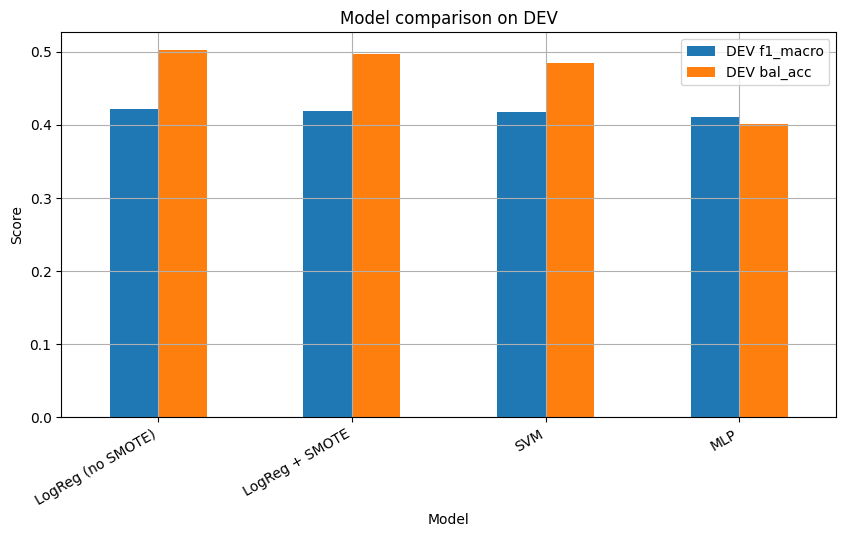

In [154]:
results = pd.DataFrame([
    {
        "Model": "LogReg (no SMOTE)",
        "Best params": "C=0.0001",
        "CV f1_macro": 0.4250,
        "DEV f1_macro": 0.4217,
        "DEV bal_acc": 0.5017,
        "DEV accuracy": 0.6344,
    },
    {
        "Model": "SVM",
        "Best params": "C=1, gamma=0.1",
        "CV f1_macro": 0.4171,
        "DEV f1_macro": 0.4176,
        "DEV bal_acc": 0.4844,
        "DEV accuracy": 0.6444,
    },
    {
        "Model": "MLP",
        "Best params": "relu, alpha=0.001, (100,100)",
        "CV f1_macro": 0.4077,
        "DEV f1_macro": 0.4111,
        "DEV bal_acc": 0.4008,
        "DEV accuracy": 0.8183,
    },
    {
        "Model": "LogReg + SMOTE",
        "Best params": "C=0.0001",
        "CV f1_macro": 0.4221,
        "DEV f1_macro": 0.4188,
        "DEV bal_acc": 0.4974,
        "DEV accuracy": 0.6253,
    },
])

results = results.sort_values("DEV f1_macro", ascending=False)
display(results)

plot_df = results.set_index("Model")[["DEV f1_macro", "DEV bal_acc"]]
plot_df.plot(kind="bar", grid=True, figsize=(10,5))
plt.title("Model comparison on DEV")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.show()


## Confronto dei modelli e scelta finale

La tabella e il grafico riportano le prestazioni dei modelli sul set di validazione (DEV),
utilizzando **macro-F1** come metrica principale e **balanced accuracy** come supporto.

La Logistic Regression senza SMOTE ottiene il miglior compromesso tra macro-F1 e balanced accuracy.
SVM e MLP non mostrano miglioramenti significativi, a fronte di un costo computazionale più elevato
(SVM) o di una gestione meno efficace dello sbilanciamento (MLP).  
L’uso di SMOTE non porta benefici apprezzabili rispetto alla Logistic Regression standard.

Per questi motivi, **la Logistic Regression senza SMOTE viene selezionata come modello finale**.


Shape Train: (160846, 21) Dev: (22978, 21) Test: (45957, 21)
Shape Train+Dev: (183824, 21)

=== FINAL TEST (Train+Dev refit) ===
TEST f1_macro: 0.4228
TEST balanced_accuracy: 0.5036

Classification report (TEST):
              precision    recall  f1-score   support

           0     0.9395    0.6532    0.7706     38012
           1     0.0319    0.2765    0.0572       926
           2     0.3547    0.5810    0.4405      7019

    accuracy                         0.6346     45957
   macro avg     0.4420    0.5036    0.4228     45957
weighted avg     0.8319    0.6346    0.7058     45957


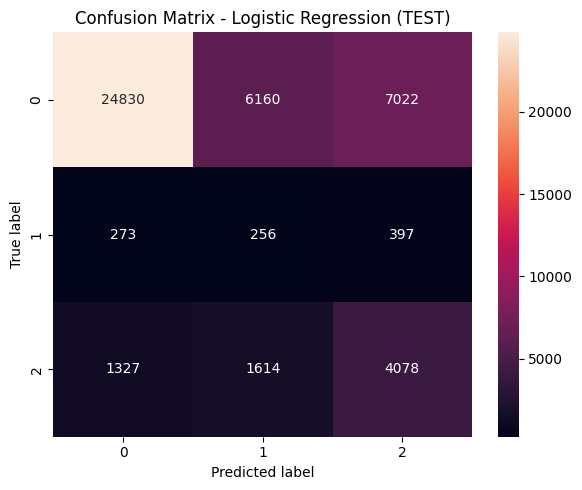

In [155]:
X_train_dev = np.vstack([X_train_scaled, X_dev_scaled])
t_train_dev = np.hstack([t_train, t_dev])

print("Shape Train:", X_train_scaled.shape, "Dev:", X_dev_scaled.shape, "Test:", X_test_scaled.shape)
print("Shape Train+Dev:", X_train_dev.shape)

final_lr = LogisticRegression(
    C=0.0001,
    class_weight="balanced",
    solver="lbfgs",
)

final_lr.fit(X_train_dev, t_train_dev)

t_test_pred = final_lr.predict(X_test_scaled)

print("\n=== FINAL TEST (Train+Dev refit) ===")
print("TEST f1_macro:", round(f1_score(t_test, t_test_pred, average="macro"), 4))
print("TEST balanced_accuracy:", round(balanced_accuracy_score(t_test, t_test_pred), 4))

print("\nClassification report (TEST):")
print(classification_report(t_test, t_test_pred, digits=4, zero_division=0))

cm_lr = confusion_matrix(t_test, t_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt="d")
plt.title("Confusion Matrix - Logistic Regression (TEST)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


## Interpretazione dei risultati

Le prestazioni ottenute mostrano un limite chiaro: la classe **prediabetes (1)** è
difficile da riconoscere, con F1 molto basso, mentre la separazione tra **no diabetes (0)** e **diabetes (2)**
risulta un po' più efficace.

Questo comportamento è coerente con:
- lo **sbilanciamento estremo** della classe 1 (≈2%)
- l’**overlap** osservato nell’EDA: molti indicatori della classe 1 assumono valori intermedi e sovrapposti
  alle altre classi, rendendo la separazione intrinsecamente complessa.


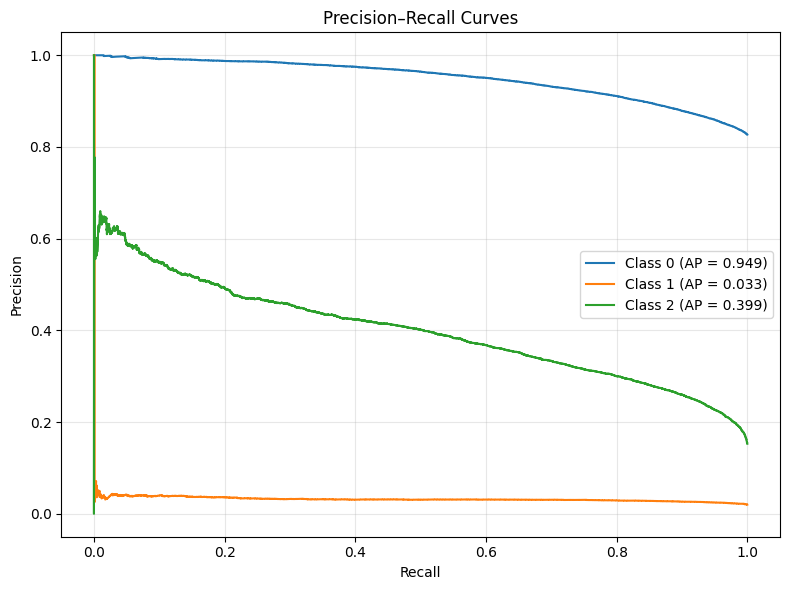

In [159]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score

# Binarize target (one-vs-rest)
classes = [0, 1, 2]
t_test_bin = label_binarize(t_test, classes=classes)

t_test_proba = final_lr.predict_proba(X_test_scaled)

plt.figure(figsize=(8, 6))

for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(
        t_test_bin[:, i],
        t_test_proba[:, i]
    )
    ap = average_precision_score(
        t_test_bin[:, i],
        t_test_proba[:, i]
    )
    
    plt.plot(
        recall,
        precision,
        label=f"Class {cls} (AP = {ap:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Le curve Precision–Recall sul set di test mostrano che il modello distingue bene
la classe 0, riesce a catturare solo parzialmente la classe di diabete, mentre incontra
notevoli difficoltà nel riconoscere la classe di prediabete. In particolare, per quest’ultima,
sia precision che recall rimangono molto bassi per la maggior parte delle soglie.